In [1]:
# ============================================================
# CELLULE 1 : IMPORTS & VÉRIFICATION GPU
# ============================================================
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.nn.utils.rnn import pad_sequence
import numpy as np
import os
import random
import matplotlib.pyplot as plt
from transformers import DistilBertModel, DistilBertTokenizer
from os.path import join as pjoin
from tqdm.notebook import tqdm
import pandas as pd

# Reproductibilité
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)

# GPU Check
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"✅ Device : {device}")
if device.type == 'cuda':
    print(f"   GPU     : {torch.cuda.get_device_name(0)}")
    print(f"   VRAM    : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

2026-02-19 14:02:38.116353: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771509758.297611      56 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771509758.351085      56 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771509758.795094      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771509758.795139      56 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771509758.795141      56 computation_placer.cc:177] computation placer alr

✅ Device : cuda
   GPU     : Tesla P100-PCIE-16GB
   VRAM    : 17.1 GB


In [2]:
# ============================================================
# CELLULE 2 : CONFIGURATION
# ============================================================
CONFIG = {
    # --- Architecture ---
    "embed_dim": 512,
    "motion_input_dim": 384,   # Auto-détecté à la cellule 3
    "dropout": 0.2,            # Légèrement réduit pour ne pas bloquer la convergence initiale

    # --- Entraînement ---
    "batch_size": 128,         # Grand batch = meilleure loss contrastive
    "learning_rate": 3e-4,     # LR de croisière (après warmup)
    "warmup_epochs": 3,        # Warmup linéaire pour éviter la stagnation initiale
    "weight_decay": 1e-2,      # Augmenté : meilleure régularisation L2 (anti-overfitting)
    "epochs": 175,
    "patience": 12,            # Early stopping
    "val_split": 0.1,
    "max_seq_len": 196,

    # --- Scheduler ---
    "scheduler_patience": 4,   # ReduceLROnPlateau patience (plus conservateur)
    "scheduler_factor": 0.5,

    # --- Augmentation ---
    "motion_noise_std": 0.002, # Bruit léger
    "time_mask_ratio": 0.1,

    # --- Fine-tuning BERT ---
    "unfreeze_bert_epoch": 10, # Laisser le modèle se stabiliser d'abord
    "bert_lr_factor": 0.03,    # LR BERT = lr * factor (très petit)

    "seed": 42,
}
# --- CHEMINS KAGGLE (NE PAS MODIFIER) ---
DATA_ROOT = '/kaggle/input/tmr-text-motion-retrieval/data/data'
TRAIN_MOTION_DIR = pjoin(DATA_ROOT, 'motions')
TRAIN_TEXT_DIR   = pjoin(DATA_ROOT, 'texts')
TEST_DIR         = pjoin(DATA_ROOT, 'test')

# Vérification
for path, name in [(TRAIN_MOTION_DIR, 'Motions'), (TRAIN_TEXT_DIR, 'Texts'), (TEST_DIR, 'Test')]:
    if os.path.exists(path):
        n = len(os.listdir(path))
        print(f"✅ {name}: {n} fichiers/dossiers")
    else:
        print(f"❌ INTROUVABLE : {path}")


✅ Motions: 6018 fichiers/dossiers
✅ Texts: 6018 fichiers/dossiers
✅ Test: 30 fichiers/dossiers


In [3]:
# ============================================================
# CELLULE 3 : AUTO-DÉTECTION DE LA DIMENSION DES MOTIONS
# ============================================================
# On lit le premier fichier pour savoir la vraie dimension des features
sample_files = [f for f in os.listdir(TRAIN_MOTION_DIR) if f.endswith('.npy')][:5]

for sf in sample_files:
    data = np.load(pjoin(TRAIN_MOTION_DIR, sf))
    print(f"  Fichier : {sf} | Shape : {data.shape}")
    CONFIG["motion_input_dim"] = data.shape[1]  # On prend la dernière valeur

print(f"\n✅ Dimension des motions détectée : {CONFIG['motion_input_dim']}")

  Fichier : 5955.npy | Shape : (19, 384)
  Fichier : 4548.npy | Shape : (22, 384)
  Fichier : 5788.npy | Shape : (48, 384)
  Fichier : 6947.npy | Shape : (71, 384)
  Fichier : 7559.npy | Shape : (110, 384)

✅ Dimension des motions détectée : 384


In [4]:
# ============================================================
# CELLULE 4 : DATASET AMÉLIORÉ
# Nouveautés :
#   - Charge TOUTES les lignes de texte (pas juste la 1ère)
#   - Augmentation des motions (bruit + time masking)
#   - Retourne la longueur réelle pour le masque de padding
# ============================================================

class TextMotionDataset(Dataset):
    def __init__(self, motion_dir, text_dir, max_len=196, augment=False):
        self.motion_dir = motion_dir
        self.text_dir   = text_dir
        self.max_len    = max_len
        self.augment    = augment
        
        # Construire la liste (motion_file, texte_ligne)
        # Chaque paire motion+ligne devient un sample INDÉPENDANT
        self.samples = []
        
        if os.path.exists(motion_dir) and os.path.exists(text_dir):
            all_motions = [f.replace('.npy', '') for f in os.listdir(motion_dir) if f.endswith('.npy')]
            for name in all_motions:
                txt_path = pjoin(text_dir, name + '.txt')
                if not os.path.exists(txt_path):
                    continue
                with open(txt_path, 'r', encoding='utf-8') as f:
                    lines = [l.strip() for l in f.readlines() if l.strip()]
                # On crée une paire par ligne de description
                for line in lines:
                    self.samples.append((name, line))
        
        print(f"📚 Dataset : {len(self.samples)} paires (texte, mouvement)")

    def __len__(self):
        return len(self.samples)

    def _augment_motion(self, motion):
        """Applique du bruit gaussien et du time masking."""
        # Bruit gaussien léger
        noise = torch.randn_like(motion) * CONFIG["motion_noise_std"]
        motion = motion + noise
        # Time masking : met à zéro un segment aléatoire
        T = motion.shape[0]
        mask_len = int(T * CONFIG["time_mask_ratio"])
        if mask_len > 0:
            start = random.randint(0, T - mask_len)
            motion[start:start+mask_len] = 0.0
        return motion

    def __getitem__(self, idx):
        name, text = self.samples[idx]
        
        # Charger le mouvement
        m_path = pjoin(self.motion_dir, name + '.npy')
        try:
            motion = np.load(m_path)
            if motion.shape[0] > self.max_len:
                # Troncature aléatoire (vs toujours début) pour augmenter la diversité
                if self.augment:
                    start = random.randint(0, motion.shape[0] - self.max_len)
                    motion = motion[start:start+self.max_len]
                else:
                    motion = motion[:self.max_len]
            motion = torch.FloatTensor(motion)
        except Exception as e:
            return None
        
        # Augmentation motion pendant l'entraînement
        if self.augment:
            motion = self._augment_motion(motion)

        return {"motion": motion, "text": text, "name": name}


def collate_fn(batch):
    batch = [b for b in batch if b is not None]
    if not batch:
        return None, None, None, None
    motions = [x['motion'] for x in batch]
    texts   = [x['text']   for x in batch]
    names   = [x['name']   for x in batch]
    motions_padded = pad_sequence(motions, batch_first=True, padding_value=0.0)
    return motions_padded, texts, None, names

print("✅ Dataset et collate_fn définis.")

✅ Dataset et collate_fn définis.


In [5]:
# ============================================================
# CELLULE 5 : MODÈLE
# - GRU Bidirectionnel + Attention Pooling
# - BERT partiellement dégelé (dernière couche dès le départ)
# - Température initiale réduite pour meilleure convergence initiale
# ============================================================

class AttentionPooling(nn.Module):
    """Apprend quels frames sont importants."""
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, x):
        # x : (B, T, D)
        weights = torch.softmax(self.attn(x), dim=1)  # (B, T, 1)
        return (x * weights).sum(dim=1)               # (B, D)


class MLPProjection(nn.Module):
    def __init__(self, input_dim, hidden_dim, output_dim, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.LayerNorm(hidden_dim),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim),
        )
    def forward(self, x):
        return self.net(x)


class TextMotionModel(nn.Module):
    def __init__(self, motion_dim, embed_dim, dropout=0.2):
        super().__init__()

        # ---- BRANCHE TEXTE : DistilBERT ----
        print("⏳ Chargement de DistilBERT...")
        self.bert = DistilBertModel.from_pretrained('distilbert-base-uncased')
        self.tokenizer = DistilBertTokenizer.from_pretrained('distilbert-base-uncased')

        # Geler tout sauf la dernière couche
        for param in self.bert.parameters():
            param.requires_grad = False
        for param in self.bert.transformer.layer[-1].parameters():
            param.requires_grad = True

        self.text_proj = MLPProjection(768, 768, embed_dim, dropout)

        # ---- BRANCHE MOUVEMENT : GRU Bidirectionnel + Attention Pooling ----
        self.gru = nn.GRU(
            input_size=motion_dim,
            hidden_size=512,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )
        self.motion_pool = AttentionPooling(1024)  # 512 * 2
        self.motion_proj = MLPProjection(1024, 1024, embed_dim, dropout)

        # Température : initialisée à 0.1 (moins agressive que 1/0.07≈14.3)
        # Permet une convergence plus douce au début
        self.log_temp = nn.Parameter(torch.tensor(np.log(0.1)))

        print(f"✅ Modèle créé | embed_dim={embed_dim} | motion_dim={motion_dim}")

    def unfreeze_bert(self):
        """Débloque les 2 dernières couches de DistilBERT (couches 4 et 5)."""
        for i, layer in enumerate(self.bert.transformer.layer):
            if i >= 4:
                for param in layer.parameters():
                    param.requires_grad = True
        print("🔓 Couches BERT 4 et 5 débloquées.")

    def get_bert_params(self):
        """Retourne les paramètres BERT entraînables."""
        return [p for p in self.bert.parameters() if p.requires_grad]

    def get_non_bert_params(self):
        """Retourne les paramètres hors BERT."""
        bert_ids = {id(p) for p in self.bert.parameters()}
        return [p for p in self.parameters() if id(p) not in bert_ids and p.requires_grad]

    def forward_text(self, text_list, device):
        inputs = self.tokenizer(
            text_list, return_tensors="pt",
            padding=True, truncation=True, max_length=128
        ).to(device)
        outputs = self.bert(**inputs)
        cls_emb  = outputs.last_hidden_state[:, 0, :]
        mean_emb = outputs.last_hidden_state.mean(dim=1)
        combined = (cls_emb + mean_emb) / 2
        return self.text_proj(combined)

    def forward_motion(self, motion_tensor):
        out, _ = self.gru(motion_tensor)        # (B, T, 1024)
        emb = self.motion_pool(out)              # (B, 1024)
        return self.motion_proj(emb)

    @property
    def temperature(self):
        return torch.clamp(self.log_temp.exp(), min=0.01, max=5.0)

print("✅ Modèle défini.")


✅ Modèle défini.


In [6]:
# ============================================================
# CELLULE 6 : LOSS CONTRASTIVE AMÉLIORÉE
# Nouveautés :
#   - Symmetric CLIP loss (identique à avant)
#   - Possibilité d'ajouter une marge (NT-Xent style)
# ============================================================

def clip_contrastive_loss(text_emb, motion_emb, log_temp):
    """Loss CLIP symétrique avec température apprise."""
    text_emb   = F.normalize(text_emb,   dim=-1)
    motion_emb = F.normalize(motion_emb, dim=-1)
    
    temp = torch.clamp(log_temp.exp(), min=0.01, max=10.0)
    logits = torch.matmul(text_emb, motion_emb.T) / temp
    
    labels = torch.arange(logits.size(0), device=logits.device)
    
    loss_t2m = F.cross_entropy(logits,   labels)  # Texte -> Motion
    loss_m2t = F.cross_entropy(logits.T, labels)  # Motion -> Texte
    
    return (loss_t2m + loss_m2t) / 2

print("✅ Loss contrastive définie.")

✅ Loss contrastive définie.


📚 Dataset : 18054 paires (texte, mouvement)
📚 Dataset : 18054 paires (texte, mouvement)
📚 Dataset : 18054 paires (texte, mouvement)
📊 Train : 16251 samples | Val : 1803 samples
   (sur 5417 motions train | 601 motions val)
⏳ Chargement de DistilBERT...


config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/268M [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

...

Epoch 029 | Train=1.0841 | Val=2.8135 | gap=-1.7294 ⚠️ overfit | R@1=0.059 R@5=0.226 R@10=0.330 | T=0.060 | LR=7.50e-05
  📉 LR réduit : 7.50e-05 → 3.75e-05


Epoch 030 [TRAIN]:   0%|          | 0/127 [00:00<?, ?it/s]

Epoch 030 | Train=1.0699 | Val=2.8129 | gap=-1.7431 ⚠️ overfit | R@1=0.060 R@5=0.222 R@10=0.334 | T=0.061 | LR=3.75e-05


Epoch 031 [TRAIN]:   0%|          | 0/127 [00:00<?, ?it/s]

Epoch 031 | Train=1.0643 | Val=2.8101 | gap=-1.7458 ⚠️ overfit | R@1=0.060 R@5=0.230 R@10=0.331 | T=0.061 | LR=3.75e-05

⏹️  Early stopping à l'epoch 31

✅ Meilleurs poids rechargés.


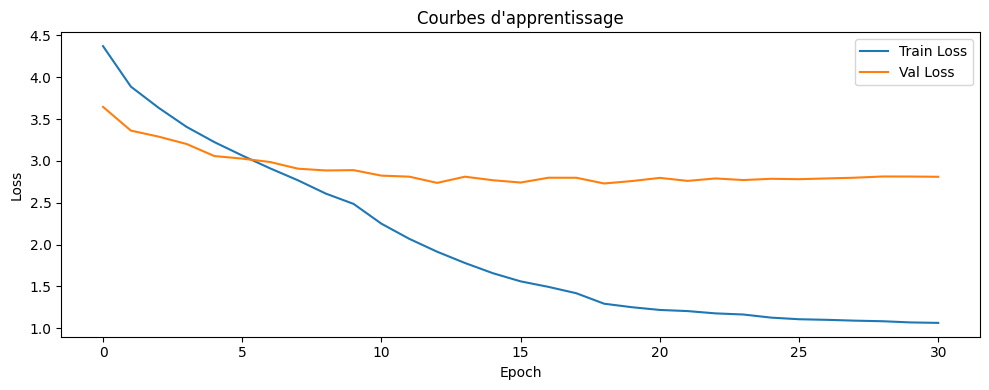

In [7]:
# ============================================================
# CELLULE 7 : BOUCLE D'ENTRAÎNEMENT COMPLÈTE
# Améliorations anti-overfitting & convergence :
#   - Warmup LR linéaire (évite la stagnation initiale)
#   - Optimizer séparé BERT / non-BERT (LR différents)
#   - Gestion correcte du scheduler au dégel de BERT
#   - Label smoothing dans la loss contrastive
#   - Détection et log du gap train/val (signal d'overfitting)
# ============================================================

def compute_recall(all_txt, all_mot, ks=(1, 5, 10)):
    """Calcule R@K depuis les embeddings CPU."""
    all_txt = F.normalize(all_txt, dim=1)
    all_mot = F.normalize(all_mot, dim=1)
    sim = torch.matmul(all_txt, all_mot.T)  # (N, N)
    n = sim.size(0)
    recalls = {}
    for k in ks:
        k = min(k, n)
        top_k = sim.topk(k, dim=1).indices  # (N, k)
        correct = (top_k == torch.arange(n).unsqueeze(1)).any(dim=1)
        recalls[k] = correct.float().mean().item()
    return recalls


def clip_contrastive_loss(text_emb, motion_emb, log_temp, label_smoothing=0.1):
    """
    Loss CLIP symétrique avec température apprise + label smoothing.
    Le label smoothing réduit la confiance excessive → régularisation efficace.
    """
    text_emb   = F.normalize(text_emb,   dim=-1)
    motion_emb = F.normalize(motion_emb, dim=-1)

    temp = torch.clamp(log_temp.exp(), min=0.01, max=5.0)
    logits = torch.matmul(text_emb, motion_emb.T) / temp

    labels = torch.arange(logits.size(0), device=logits.device)

    loss_t2m = F.cross_entropy(logits,   labels, label_smoothing=label_smoothing)
    loss_m2t = F.cross_entropy(logits.T, labels, label_smoothing=label_smoothing)

    return (loss_t2m + loss_m2t) / 2


def get_lr_with_warmup(epoch, warmup_epochs, base_lr):
    """Warmup linéaire : lr monte de 0 à base_lr sur warmup_epochs."""
    if epoch <= warmup_epochs:
        return base_lr * epoch / warmup_epochs
    return base_lr


def train():
    random.seed(CONFIG["seed"])
    torch.manual_seed(CONFIG["seed"])
    np.random.seed(CONFIG["seed"])

    # ---- 1. Données ----
    full_dataset = TextMotionDataset(
        TRAIN_MOTION_DIR, TRAIN_TEXT_DIR,
        max_len=CONFIG["max_seq_len"], augment=False
    )

    # Split par noms de fichiers (pas par indices) pour éviter la fuite de données
    all_names = sorted({name for name, _ in full_dataset.samples})
    random.shuffle(all_names)

    n_val_names = int(len(all_names) * CONFIG["val_split"])
    val_names   = set(all_names[:n_val_names])
    train_names = set(all_names[n_val_names:])

    train_samples = [(n, t) for n, t in full_dataset.samples if n in train_names]
    val_samples   = [(n, t) for n, t in full_dataset.samples if n in val_names]

    train_dataset = TextMotionDataset(
        TRAIN_MOTION_DIR, TRAIN_TEXT_DIR,
        max_len=CONFIG["max_seq_len"], augment=True
    )
    train_dataset.samples = train_samples

    val_dataset = TextMotionDataset(
        TRAIN_MOTION_DIR, TRAIN_TEXT_DIR,
        max_len=CONFIG["max_seq_len"], augment=False
    )
    val_dataset.samples = val_samples

    print(f"📊 Train : {len(train_samples)} samples | Val : {len(val_samples)} samples")
    print(f"   (sur {len(train_names)} motions train | {len(val_names)} motions val)")

    train_loader = DataLoader(
        train_dataset, batch_size=CONFIG["batch_size"],
        shuffle=True, collate_fn=collate_fn, num_workers=2, pin_memory=True
    )
    val_loader = DataLoader(
        val_dataset, batch_size=CONFIG["batch_size"],
        shuffle=False, collate_fn=collate_fn, num_workers=2, pin_memory=True
    )

    # ---- 2. Modèle ----
    model = TextMotionModel(
        CONFIG["motion_input_dim"],
        CONFIG["embed_dim"],
        CONFIG["dropout"]
    ).to(device)

    # ---- 3. Optimizer avec groupes séparés ----
    # (important : BERT reçoit un LR bien plus petit pour ne pas oublier)
    def make_optimizer(bert_unfrozen=False):
        non_bert_params = model.get_non_bert_params()
        if bert_unfrozen:
            bert_params = model.get_bert_params()
            param_groups = [
                {"params": non_bert_params, "lr": CONFIG["learning_rate"]},
                {"params": bert_params,     "lr": CONFIG["learning_rate"] * CONFIG["bert_lr_factor"]},
            ]
        else:
            param_groups = [{"params": non_bert_params, "lr": CONFIG["learning_rate"]}]
        return torch.optim.AdamW(param_groups, weight_decay=CONFIG["weight_decay"])

    optimizer = make_optimizer(bert_unfrozen=False)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min',
        factor=CONFIG["scheduler_factor"],
        patience=CONFIG["scheduler_patience"]
    )

    best_val_loss    = float('inf')
    patience_counter = 0
    best_weights     = None
    bert_unfrozen    = False

    train_losses, val_losses = [], []

    print(f"\n🚀 Démarrage — {CONFIG['epochs']} epochs max | warmup={CONFIG['warmup_epochs']} epochs\n")

    for epoch in range(1, CONFIG["epochs"] + 1):

        # ---- Warmup LR manuel ----
        if epoch <= CONFIG["warmup_epochs"]:
            target_lr = get_lr_with_warmup(epoch, CONFIG["warmup_epochs"], CONFIG["learning_rate"])
            for pg in optimizer.param_groups:
                # Ne pas toucher le groupe BERT si présent (il a son propre LR)
                if pg.get("lr", 0) > CONFIG["learning_rate"] * CONFIG["bert_lr_factor"] * 2:
                    pg["lr"] = target_lr

        # ---- Dégel progressif de BERT ----
        if epoch == CONFIG["unfreeze_bert_epoch"] and not bert_unfrozen:
            model.unfreeze_bert()
            bert_unfrozen = True
            # Recréer l'optimizer avec le groupe BERT (LR très faible)
            optimizer = make_optimizer(bert_unfrozen=True)
            scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                optimizer, mode='min',
                factor=CONFIG["scheduler_factor"],
                patience=CONFIG["scheduler_patience"]
            )
            print(f"  🔓 BERT dégelé — LR BERT={CONFIG['learning_rate']*CONFIG['bert_lr_factor']:.2e}")

        # -------- TRAIN --------
        model.train()
        total_train_loss = 0.0
        n_batches = 0

        pbar = tqdm(train_loader, desc=f"Epoch {epoch:03d} [TRAIN]", leave=False)
        for motions, texts, _, _ in pbar:
            if motions is None:
                continue
            motions = motions.to(device, non_blocking=True)

            text_feat   = model.forward_text(texts, device)
            motion_feat = model.forward_motion(motions)

            loss = clip_contrastive_loss(text_feat, motion_feat, model.log_temp)

            optimizer.zero_grad()
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            total_train_loss += loss.item()
            n_batches += 1
            pbar.set_postfix({"loss": f"{loss.item():.4f}", "T": f"{model.temperature.item():.3f}"})

        avg_train = total_train_loss / max(n_batches, 1)
        train_losses.append(avg_train)

        # -------- VALIDATION --------
        model.eval()
        total_val_loss = 0.0
        n_val_batches  = 0
        all_txt_embs, all_mot_embs = [], []

        with torch.no_grad():
            for motions, texts, _, _ in val_loader:
                if motions is None:
                    continue
                motions = motions.to(device, non_blocking=True)

                text_feat   = model.forward_text(texts, device)
                motion_feat = model.forward_motion(motions)

                loss = clip_contrastive_loss(text_feat, motion_feat, model.log_temp, label_smoothing=0.0)
                total_val_loss += loss.item()
                n_val_batches  += 1

                all_txt_embs.append(text_feat.cpu())
                all_mot_embs.append(motion_feat.cpu())

        avg_val = total_val_loss / max(n_val_batches, 1)
        val_losses.append(avg_val)

        all_txt = torch.cat(all_txt_embs)
        all_mot = torch.cat(all_mot_embs)
        recalls = compute_recall(all_txt, all_mot)

        # Gap train/val : signal d'overfitting
        gap = avg_train - avg_val
        gap_str = f"gap={gap:+.4f}"
        if avg_val > avg_train + 0.05:
            gap_str += " ⚠️ overfit"

        cur_lr = optimizer.param_groups[0]['lr']
        print(f"Epoch {epoch:03d} | Train={avg_train:.4f} | Val={avg_val:.4f} | {gap_str} "
              f"| R@1={recalls[1]:.3f} R@5={recalls[5]:.3f} R@10={recalls[10]:.3f} "
              f"| T={model.temperature.item():.3f} | LR={cur_lr:.2e}")

        # Scheduler (pas pendant le warmup)
        if epoch > CONFIG["warmup_epochs"]:
            old_lr = optimizer.param_groups[0]['lr']
            scheduler.step(avg_val)
            new_lr = optimizer.param_groups[0]['lr']
            if new_lr < old_lr - 1e-12:
                print(f"  📉 LR réduit : {old_lr:.2e} → {new_lr:.2e}")

        # -------- Early Stopping --------
        if avg_val < best_val_loss:
            best_val_loss = avg_val
            patience_counter = 0
            best_weights = {k: v.cpu().clone() for k, v in model.state_dict().items()}
            torch.save(best_weights, "best_model.pth")
            print(f"  💾 Meilleur modèle sauvegardé (val_loss={best_val_loss:.4f})")
        else:
            patience_counter += 1
            if patience_counter >= CONFIG["patience"]:
                print(f"\n⏹️  Early stopping à l'epoch {epoch}")
                break

    # Recharger les meilleurs poids
    model.load_state_dict({k: v.to(device) for k, v in best_weights.items()})
    print("\n✅ Meilleurs poids rechargés.")

    # Courbe d'apprentissage
    plt.figure(figsize=(10, 4))
    plt.plot(train_losses, label='Train Loss')
    plt.plot(val_losses,   label='Val Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.title("Courbes d'apprentissage")
    plt.legend()
    plt.tight_layout()
    plt.savefig('learning_curves.png', dpi=150)
    plt.show()

    return model


# ---- LANCEMENT ----
if os.path.exists(TRAIN_MOTION_DIR):
    model = train()
else:
    print("❌ Données introuvables — vérifie tes chemins.")


In [8]:
# ============================================================
# CELLULE 8 : ÉVALUATION SUR LE TEST SET (train split)
# Permet de voir les métriques finales sur les données d'entraînement.
# NOTE : L'évaluation réelle se fait via submission.csv sur Kaggle.
# ============================================================

def evaluate_on_dataset(model, motion_dir, text_dir, label="Eval"):
    print(f"\n📊 Évaluation sur : {label}")
    model.eval()
    
    dataset = TextMotionDataset(motion_dir, text_dir, max_len=CONFIG["max_seq_len"], augment=False)
    if len(dataset) == 0:
        print("⚠️ Dataset vide.")
        return
    
    loader = DataLoader(dataset, batch_size=64, collate_fn=collate_fn, num_workers=2)
    all_txt, all_mot = [], []
    
    with torch.no_grad():
        for motions, texts, _, _ in tqdm(loader):
            if motions is None: continue
            motions = motions.to(device)
            all_txt.append(model.forward_text(texts, device).cpu())
            all_mot.append(model.forward_motion(motions).cpu())
    
    all_txt = torch.cat(all_txt)
    all_mot = torch.cat(all_mot)
    recalls = compute_recall(all_txt, all_mot, ks=(1, 5, 10))
    
    n = all_txt.shape[0]
    print(f"\n🏆 RÉSULTATS ({n} samples) :")
    for k, v in recalls.items():
        print(f"   R@{k:<3d}: {v:.2%}")

evaluate_on_dataset(model, TRAIN_MOTION_DIR, TRAIN_TEXT_DIR, label="Train set")


📊 Évaluation sur : Train set
📚 Dataset : 18054 paires (texte, mouvement)


  0%|          | 0/283 [00:00<?, ?it/s]


🏆 RÉSULTATS (18054 samples) :
   R@1  : 19.39%
   R@5  : 66.17%
   R@10 : 76.50%


In [9]:
# ============================================================
# CELLULE 9 : GÉNÉRATION DU FICHIER SUBMISSION.CSV
# Identique à avant mais adapté au nouveau modèle.
# ============================================================

def generate_submission(model, test_root_dir, output_path="submission.csv"):
    model.eval()
    print(f"\n📂 Test dir : {test_root_dir}")
    
    subfolders = sorted(
        [f for f in os.listdir(test_root_dir) if os.path.isdir(pjoin(test_root_dir, f))],
        key=lambda x: int(x) if x.isdigit() else x
    )
    print(f"   {len(subfolders)} requêtes trouvées.")
    
    results = []
    
    for folder_name in tqdm(subfolders, desc="Génération submission"):
        folder_path = pjoin(test_root_dir, folder_name)
        
        # Texte de la requête
        text_path = pjoin(folder_path, 'text.txt')
        if not os.path.exists(text_path):
            continue
        with open(text_path, 'r', encoding='utf-8') as f:
            query_text = f.read().strip().split('\n')[0]  # Première ligne
        
        # Fichiers motions candidats
        motion_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.npy') and 'motion' in f])
        
        candidates_motions, candidates_ids = [], []
        for m_file in motion_files:
            try:
                c_id = int(m_file.replace('motion_', '').replace('.npy', ''))
            except:
                c_id = m_file
            candidates_ids.append(c_id)
            try:
                m_data = np.load(pjoin(folder_path, m_file))
                if m_data.shape[0] > CONFIG["max_seq_len"]:
                    m_data = m_data[:CONFIG["max_seq_len"]]
                candidates_motions.append(torch.FloatTensor(m_data))
            except:
                candidates_motions.append(torch.zeros(CONFIG["max_seq_len"], CONFIG["motion_input_dim"]))
        
        if not candidates_motions:
            continue
        
        with torch.no_grad():
            text_emb = F.normalize(model.forward_text([query_text], device), dim=-1)
            padded   = pad_sequence(candidates_motions, batch_first=True, padding_value=0.0).to(device)
            mot_embs = F.normalize(model.forward_motion(padded), dim=-1)
            scores   = torch.matmul(text_emb, mot_embs.T).squeeze(0)
            top_k    = min(10, len(candidates_ids))
            top_idx  = torch.sort(scores, descending=True).indices[:top_k].cpu().numpy()
            ranked   = [candidates_ids[i] for i in top_idx]
        
        row = {'query_id': folder_name}
        for rank, c_id in enumerate(ranked):
            row[f'candidate_{rank+1}'] = c_id
        for rank in range(len(ranked), 10):
            row[f'candidate_{rank+1}'] = ranked[-1]
        results.append(row)
    
    df = pd.DataFrame(results)
    cols = ['query_id'] + [f'candidate_{i}' for i in range(1, 11)]
    df = df[cols]
    df.to_csv(output_path, index=False)
    print(f"\n✅ {output_path} généré avec {len(df)} lignes !")
    print(df.head())
    return df


if os.path.exists(TEST_DIR):
    df_submit = generate_submission(model, TEST_DIR)
else:
    print(f"❌ Dossier test introuvable : {TEST_DIR}")


📂 Test dir : /kaggle/input/tmr-text-motion-retrieval/data/data/test
   30 requêtes trouvées.


Génération submission:   0%|          | 0/30 [00:00<?, ?it/s]


✅ submission.csv généré avec 30 lignes !
  query_id  candidate_1  candidate_2  candidate_3  candidate_4  candidate_5  \
0        1           17           30           15           28            3   
1        2           11            7           10           29            4   
2        3           30           28           18           21            4   
3        4            7           20           31           24            1   
4        5           28            3            4            8           14   

   candidate_6  candidate_7  candidate_8  candidate_9  candidate_10  
0           23            6           16           10             7  
1            8            3           12            1            18  
2           13           19            9           23             6  
3            3           22           27           15            26  
4           27           24            1           31            25  
